# Traffic Analysis

In [35]:
import geopandas as gpd
import osmnx as ox
import network_functions as nf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

from collections import Counter, defaultdict
from itertools import pairwise 
from shapely.geometry import Polygon
from utils import plot_transition_matrix

## Project Area Scope

In [36]:
### Area of Interest for Project Prompt ###
# this is copy & pasted from Lat-Lon format in Google Maps
top_left = (38.543680985703226, -121.7440795432951)
top_right = (38.545050789861584, -121.73714115854816)
bottom_right = (38.54333958192836, -121.73654298866767)
bottom_left = (38.54217103842081, -121.74365700939322)

def ll_to_xy(ll):
    return (ll[1], ll[0])  # (lat,lon) -> (lon,lat)

aoi_poly_wgs84 = Polygon([
    ll_to_xy(top_left),
    ll_to_xy(top_right),
    ll_to_xy(bottom_right),
    ll_to_xy(bottom_left),
    ll_to_xy(top_left),
])

aoi_wgs84 = gpd.GeoDataFrame(geometry=[aoi_poly_wgs84], crs="EPSG:4326")
aoi_3310 = aoi_wgs84.to_crs("EPSG:3310")

## EDA Trips

In [37]:
trips_df = pd.read_parquet("data/replica-itc_2025-10_28_25-trips_dataset.parquet")

### Where are people going to?

In [38]:
car_trips = trips_df.copy()[trips_df["primary_mode"].str.contains("auto")].reset_index()

trip_purposes = (
    car_trips.groupby("trip_purpose")["previous_trip_purpose"]
).value_counts().unstack().fillna(0)

# --- Transition Matrix Calculation ---
col_sums = trip_purposes.sum(axis=0).replace(0, np.nan)  # avoid divide-by-zero
trip_transition = trip_purposes.div(col_sums, axis=1).fillna(0)
plot_transition_matrix(trip_transition)

## Traffic Counts

In [39]:
location = "Davis, California, USA"
poly = ox.geocode_to_gdf(location)
G = ox.graph_from_place(location, network_type="drive")

### Origin-Dest Pair Nodes

In [40]:
origin_nodes = ox.nearest_nodes(
    G, car_trips["origin_bgrp_lng_2020"], car_trips["origin_bgrp_lat_2020"]
)
destination_nodes = ox.nearest_nodes(
    G, car_trips["destination_bgrp_lng_2020"], car_trips["destination_bgrp_lat_2020"]
)

dists, paths = nf.path_dijkstra(
    origins=origin_nodes,
    destinations=destination_nodes, #type: ignore
    G=G,
    origins_in_nodes=True,
    destinations_in_nodes=True,
    pairs=True,
    verbose=True,
)

od_counts = Counter(zip(origin_nodes, destination_nodes))

edges = defaultdict(int)
for (origin, destination), path in paths.items():
    k = od_counts.get((origin, destination), 1)
    for u, v in pairwise(path):
        edges[(u, v)] += k

edge = ox.graph_to_gdfs(G, nodes=False, edges=True)
edge_reset = edge.reset_index()

# vectorized (no row-wise apply)
edge_reset["uv"] = list(zip(edge_reset["u"], edge_reset["v"]))
edge_reset["usage"] = edge_reset["uv"].map(edges).fillna(0).astype(int)

edge_with_usage = edge_reset.drop(columns=["uv"]).set_index(["u", "v", "key"])

edges_df = edge_with_usage.assign(use_bin=np.log1p(edge_with_usage["usage"]) // 1)


pairs chosen
sources made. length 49


100%|██████████| 49/49 [00:00<00:00, 171.63it/s]


Text(0, 0.5, 'Number of Edges')

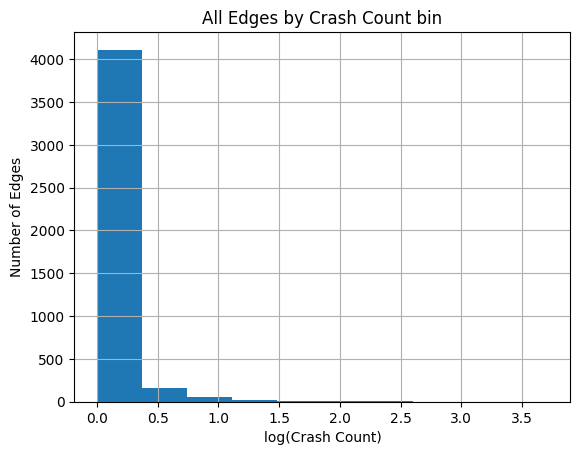

In [41]:
crashes = pd.read_csv('data/davis_crashes.csv')
crashes['POINT_X'] = crashes['POINT_X'].fillna(crashes['LONGITUDE'])
crashes['POINT_Y'] = crashes['POINT_Y'].fillna(crashes['LATITUDE'])
crashes = crashes[~crashes['POINT_X'].isna() & ~crashes['POINT_Y'].isna()]
crashes = gpd.GeoDataFrame(crashes, geometry=gpd.points_from_xy(crashes.POINT_X, crashes.POINT_Y), crs='EPSG:4326')
crashes = crashes.to_crs(poly.crs)

crash_edges = ox.nearest_edges(G, crashes['POINT_X'], crashes['POINT_Y'])
crash_counts = Counter(crash_edges)
edges_crash = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index()

edges_crash["crash_count"] = edges_crash[["u","v","key"]].apply(tuple, axis=1).map(crash_counts).fillna(0).astype(int)
edges_crash["crash_bin"] = (np.log1p(edges_crash["crash_count"]))
edges_crash['crash_bin'].hist()

plt.title('All Edges by Crash Count bin')
plt.xlabel('log(Crash Count)')
plt.ylabel('Number of Edges')

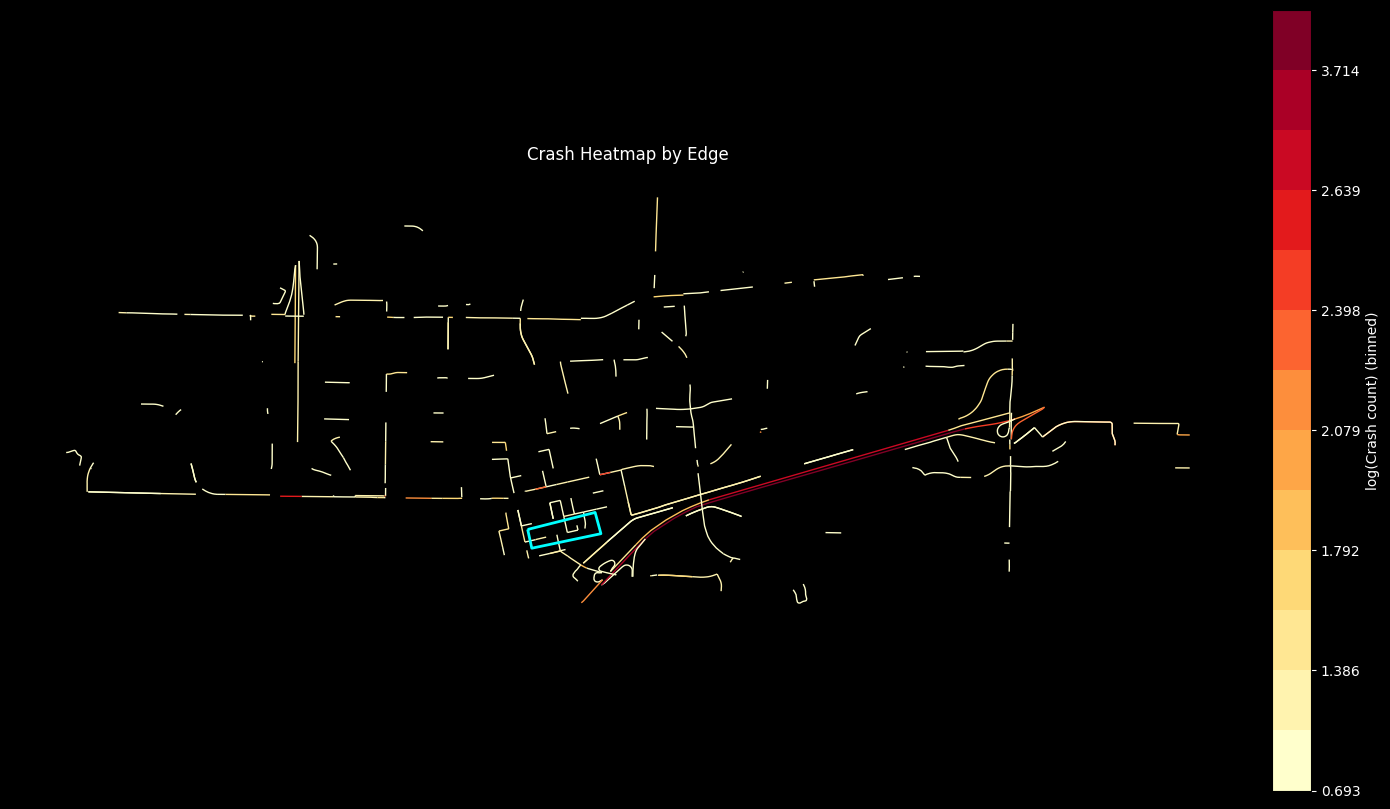

In [42]:
gdf = edges_crash[edges_crash["crash_count"] > 0].copy()

# If still in WGS84, project to Web Mercator for nicer proportions
if gdf.crs is not None and gdf.crs.to_epsg() == 4326:
    gdf = gdf.to_crs(3857)

cmap = plt.cm.YlOrRd

bins = np.sort(gdf["crash_bin"].unique())
if len(bins) == 1:
    bins = np.array([bins[0] - 1, bins[0] + 1])
norm = mcolors.BoundaryNorm(
    boundaries=np.r_[bins, bins[-1] + 1], ncolors=cmap.N, clip=True
)

fig, ax = plt.subplots(figsize=(14, 14))
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

gdf.plot(ax=ax, column="crash_bin", cmap=cmap, norm=norm, linewidth=1.0, alpha=1.0)

ax.set_axis_off()
ax.set_title("Crash Heatmap by Edge", color="white", pad=12)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("log(Crash count) (binned)", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="white")

plt.tight_layout()
# Add area of interest polygon
aoi_3310.to_crs(3857).boundary.plot(ax=ax, color="cyan", linewidth=2.0)
plt.show()


In [43]:
car_trips.columns

Index(['index', 'activity_id', 'origin_bgrp_2020', 'destination_bgrp_2020',
       'destination_trct_2020', 'destination_cty_2020', 'destination_st_2020',
       'primary_mode', 'trip_purpose', 'previous_trip_purpose',
       'trip_start_time', 'trip_end_time', 'trip_duration_minutes',
       'trip_distance_miles', 'vehicle_type', 'vehicle_fuel_type',
       'transit_submode', 'transit_agency', 'transit_route', 'origin_land_use',
       'origin_building_use', 'destination_building_use',
       'trip_taker_person_id', 'trip_taker_household_id', 'trip_taker_age',
       'trip_taker_sex', 'trip_taker_race_ethnicity',
       'trip_taker_employment_status', 'trip_taker_individual_income',
       'trip_taker_commute_mode', 'trip_taker_household_size',
       'trip_taker_household_income', 'trip_taker_available_vehicles',
       'trip_taker_industry', 'trip_taker_building_type',
       'trip_taker_school_grade_attending', 'trip_taker_education',
       'trip_taker_tenure', 'trip_taker_languag